# Explicite Finate Difference

In [2]:
from enum import Enum
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as colors
import copy

In [3]:
class OptionBasicType(Enum):
	CALL = "CALL"
	PUT = "PUT"
	
class OptionExerciseType(Enum):
	EUROPEAN = "EUROPEAN"
	AMERICAN = "AMERICAN"

class DividendType(Enum):
	FIXED_AMOUNT = "FIXED_AMOUNT"
	FIXED_YIELD = "FIXED_YIELD"

In [4]:
class EFD():
    def __init__(
        self,
        sigma_min: float,
        sigma_max: float,
        option_basic_type: OptionBasicType,
        option_exercise_type: OptionExerciseType,
        expiry_date: datetime,
        T0: datetime,
        strike_price: float,
        barrier_price: float = None,
        r: float = 0.0,

        delta_t: float = 0.01, # in year
        delta_s: float = 0.01,
        
        dividend_type: DividendType = DividendType.FIXED_AMOUNT,
        dividend_yield: float = 0.0,
        dividend_date: datetime = None,

        verbose: bool = True,

    ) -> None:
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max
        self.option_basic_type = option_basic_type
        self.option_exercise_type = option_exercise_type
        self.expiry_date = expiry_date
        self.T0 = T0
        self.strike_price = strike_price
        self.barrier_price = barrier_price
        self.r = r

        self.dividend_type = dividend_type
        self.delta_t = delta_t
        self.delta_s = delta_s

        self.dividend_yield = dividend_yield
        self.dividend_date = dividend_date
        self.dividend_done = False

        self.verbose = verbose
        
        self.initialize_grid()

    def payoff(self, S):
        if self.option_basic_type == OptionBasicType.CALL:
            return np.where(S < self.barrier_price,np.maximum(S - self.strike_price, 0), 0)
        elif self.option_basic_type == OptionBasicType.PUT:
            return np.where(S > self.barrier_price,np.maximum(self.strike_price - S, 0), 0)
        else:
            raise ValueError("Invalid option basic type")


    # S(underlying price) = i * delta_s is in comlumn. When i=0 then the price is 0, when i=N then the price is N*delta_s.
    # t(time) = j * delta_t is in row. When j=0 then the time is expiry date, when j=M then the time is T0.
    def initialize_grid(self):
        if self.barrier_price is None:
            self.N = int(3 * self.strike_price / self.delta_s)
        else:
            if self.option_basic_type == OptionBasicType.CALL:
                self.N = int(self.barrier_price / self.delta_s)
            elif self.option_basic_type == OptionBasicType.PUT:
                self.N = int(self.strike_price * 3 / self.delta_s)
        self.M = int((self.expiry_date - self.T0).days / 365 / self.delta_t)
        self.grid = np.zeros((self.N + 1, self.M + 1))

        # We will also create grids for Greeks, so we can analyze them later.
        self.delta_grid = np.zeros_like(self.grid)
        self.theta_grid = np.zeros_like(self.grid)
        self.gamma_grid = np.zeros_like(self.grid)


        if self.verbose:
            print(f"Initialized grid with shape: {self.grid.shape}")

        # Right boudary condition for expired option, when time is 0, the option value is the payoff.
        self.grid[:, 0] = self.payoff(np.arange(self.N + 1) * self.delta_s)

        if self.option_basic_type == OptionBasicType.CALL:
            # Left boundary condition for underlying price is 0, the option value is 0.
            self.grid[0, :] = 0.0

            if self.barrier_price is None:
                raise NotImplementedError("Option with no barrier is not implemented yet")
            else:
                # Upper boundary condition for underlying price is barrier price, the option value is 0.
                self.grid[self.N, :] = 0.0
        elif self.option_basic_type == OptionBasicType.PUT:
            self.grid[:int(self.barrier_price / self.delta_s) + 1, :] = 0

            if self.barrier_price is None:
                raise NotImplementedError("Option with no barrier is not implemented yet")
            else:
                self.grid[self.N, :] = 0.0

        self.dividend_done = False

        # Here we initialize variables for future plotring

        self.optimal_sigma_grid = np.zeros((self.N + 1, self.M + 1)) + 0.5

        self.american_exercise = np.zeros((self.N + 1, self.M + 1), dtype=bool)

    
    def calculate_grid(self):
        i_arr = np.arange(1, self.N)        

        for j in range(1,self.M + 1):
            # We calculate using numpy array, so we can calculate the whole column at once.

            prev_col = self.grid[:, j - 1]
            gamma = (prev_col[2:] - 2 * prev_col[1:-1] + prev_col[:-2]) / (self.delta_s ** 2)

            # We use worst case scenario sigma
            sigma = np.where(gamma > 0, self.sigma_max, self.sigma_min)
            self.optimal_sigma_grid[0,j] = 0.5
            self.optimal_sigma_grid[-1,j] = 0.5
            self.optimal_sigma_grid[1:-1,j] = np.where(gamma >= 0, np.where(gamma == 0, 0.5, 1), 0)

            p_u = 0.5 * self.delta_t * (sigma ** 2 * (i_arr ** 2) + self.r * i_arr)
            p_m = 1 - self.delta_t * (sigma ** 2 * (i_arr ** 2) + self.r)
            p_d = 0.5 * self.delta_t * (sigma ** 2 * (i_arr ** 2) - self.r * i_arr)

            self.grid[1:-1,j] = p_u * prev_col[2:] + p_m * prev_col[1:-1] + p_d * prev_col[:-2]

            if self.option_basic_type == OptionBasicType.PUT and self.barrier_price is not None:
                self.grid[:int(self.barrier_price / self.delta_s) + 1, j] = 0

            current_simulated_date = self.expiry_date - timedelta(days=j * self.delta_t * 365)

            if self.dividend_done == False and self.dividend_date is not None and current_simulated_date <= self.dividend_date:
                if self.dividend_type == DividendType.FIXED_AMOUNT:
                    dividend_in_delta_s = int(self.dividend_yield / self.delta_s)

                    S_shifted = (np.arange(1,self.N) - dividend_in_delta_s).clip(0, self.N)

                    self.grid[1:-1,j] = self.grid[S_shifted,j] 

                else:
                    S_shifted = ((1 - self.dividend_yield) * np.arange(1,self.N) * self.delta_s)

                    self.grid[1:-1,j] = np.interp(S_shifted, np.arange(self.N + 1) * self.delta_s, self.grid[:, j])


                self.dividend_done = True
                    

            if self.option_exercise_type == OptionExerciseType.AMERICAN:
                self.american_exercise[1:-1,j] = self.grid[1:-1,j] < self.payoff(i_arr * self.delta_s) 
                self.grid[1:-1,j] = np.maximum(self.grid[1:-1,j], self.payoff(i_arr * self.delta_s))
                # We mark the exercise points for American option

            
            # We calculate Greeks for analysis, we use central difference for delta and gamma, and forward difference for theta.
            self.delta_grid[1:-1, j] = (self.grid[2:, j] - self.grid[:-2, j]) / (2 * self.delta_s)
            self.gamma_grid[1:-1, j] = (self.grid[2:, j] - 2*self.grid[1:-1, j] + self.grid[:-2, j]) / (self.delta_s ** 2)
            self.theta_grid[1:-1, j] = (self.grid[1:-1, j] - prev_col[1:-1]) / self.delta_t




    def get_option_price(self, S0):
        i = int(S0 / self.delta_s)
        j = self.M
        if i > self.N or j > self.M:
            raise ValueError("S0 is out of grid range")
        return self.grid[i, j]
    
    def get_option_prices_T0(self):
        return self.grid[:, -1]
    

    # # Dodane do analizy wpływu zmienności
    # def calculate_grid_const_vol(self, sigma):
    #     i_arr = np.arange(1, self.N)        

    #     for j in range(1,self.M + 1):
    #         # We calculate using numpy array, so we can calculate the whole column at once.

    #         prev_col = self.grid[:, j - 1]
    #         gamma = (prev_col[2:] - 2 * prev_col[1:-1] + prev_col[:-2]) / (self.delta_s ** 2)

    #         p_u = 0.5 * self.delta_t * (sigma ** 2 * (i_arr ** 2) + self.r * i_arr)
    #         p_m = 1 - self.delta_t * (sigma ** 2 * (i_arr ** 2) + self.r)
    #         p_d = 0.5 * self.delta_t * (sigma ** 2 * (i_arr ** 2) - self.r * i_arr)

    #         self.grid[1:-1,j] = p_u * prev_col[2:] + p_m * prev_col[1:-1] + p_d * prev_col[:-2]

    #         if self.option_exercise_type == OptionExerciseType.AMERICAN:
    #             self.american_exercise[1:-1,j] = self.grid[1:-1,j] < self.payoff(i_arr * self.delta_s)
    #             self.grid[1:-1,j] = np.maximum(self.grid[1:-1,j], self.payoff(i_arr * self.delta_s))
    #             # We mark the exercise points for American option


In [5]:
efd_eur_call = EFD(
    sigma_min=0.2,
    sigma_max=0.3,
    option_basic_type=OptionBasicType.CALL,
    option_exercise_type=OptionExerciseType.EUROPEAN,
    expiry_date=datetime(2026, 12, 31),
    T0=datetime(2026, 1, 1),
    strike_price=3200,
    barrier_price=3600,
    r=0.05,
    
    delta_t=1/(365 * 100),
    delta_s=10,

    dividend_type=DividendType.FIXED_AMOUNT,
    dividend_yield=300,
    dividend_date=datetime(2026, 6, 30),

    verbose=True
)

efd_eur_put = EFD(
    sigma_min=0.2,
    sigma_max=0.3,
    option_basic_type=OptionBasicType.PUT,
    option_exercise_type=OptionExerciseType.EUROPEAN,
    expiry_date=datetime(2026, 12, 31),
    T0=datetime(2026, 1, 1),
    strike_price=3200,
    barrier_price=2800,
    r=0.05,
    
    delta_t=1/(365 * 250),
    delta_s=10,

    dividend_type=DividendType.FIXED_AMOUNT,
    dividend_yield=300,
    dividend_date=datetime(2026, 6, 30),

    verbose=True
)

efd_ame_call = EFD(
    sigma_min=0.2,
    sigma_max=0.3,
    option_basic_type=OptionBasicType.CALL,
    option_exercise_type=OptionExerciseType.AMERICAN,
    expiry_date=datetime(2026, 12, 31),
    T0=datetime(2026, 1, 1),
    strike_price=3200,
    barrier_price=3600,
    r=0.05,
    
    delta_t=1/(365 * 100),
    delta_s=10,

    dividend_type=DividendType.FIXED_AMOUNT,
    dividend_yield=300,
    dividend_date=datetime(2026, 6, 30),

    verbose=True
)

efd_ame_put = EFD(
    sigma_min=0.2,
    sigma_max=0.3,
    option_basic_type=OptionBasicType.PUT,
    option_exercise_type=OptionExerciseType.AMERICAN,
    expiry_date=datetime(2026, 12, 31),
    T0=datetime(2026, 1, 1),
    strike_price=3200,
    barrier_price=2800,
    r=0.05,
    
    delta_t=1/(365 * 250),
    delta_s=10,

    dividend_type=DividendType.FIXED_AMOUNT,
    dividend_yield=300,
    dividend_date=datetime(2026, 6, 30),

    verbose=True
)

efd_eur_call.calculate_grid()
option_prices = efd_eur_call.get_option_prices_T0()

efd_eur_put.calculate_grid()
option_prices_put = efd_eur_put.get_option_prices_T0()

efd_ame_call.calculate_grid()
option_prices_ame_call = efd_ame_call.get_option_prices_T0()

efd_ame_put.calculate_grid()
option_prices_ame_put = efd_ame_put.get_option_prices_T0()

Initialized grid with shape: (361, 36401)
Initialized grid with shape: (961, 91001)
Initialized grid with shape: (361, 36401)
Initialized grid with shape: (961, 91001)


# Pierwszy eksperyment 
Pokazuje cenę opcji w T0 w zależności od ceny instrumentu bazowego

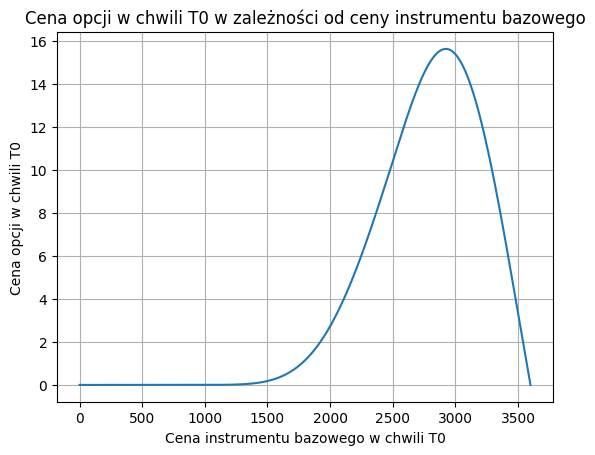

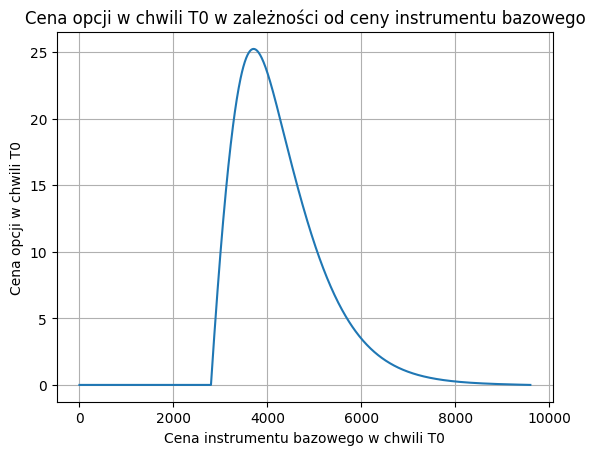

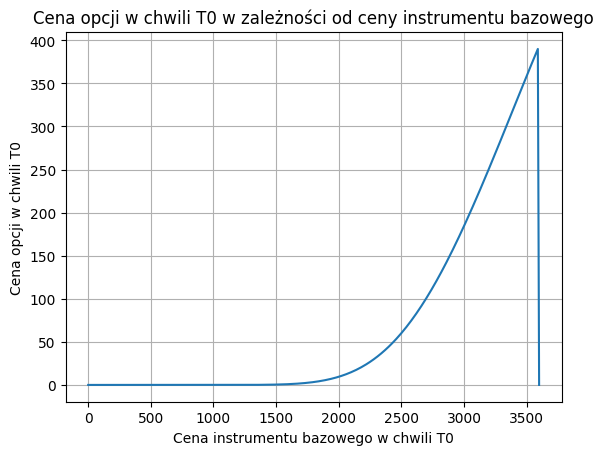

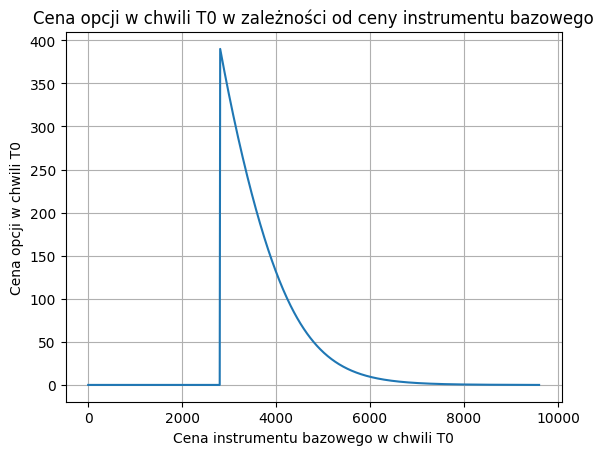

In [6]:
X = np.arange(efd_eur_call.N + 1) * efd_eur_call.delta_s
plt.plot(X, option_prices)
plt.xlabel("Cena instrumentu bazowego w chwili T0")
plt.ylabel("Cena opcji w chwili T0")
plt.title("Cena opcji w chwili T0 w zależności od ceny instrumentu bazowego")
plt.grid()
plt.show()

X = np.arange(efd_eur_put.N + 1) * efd_eur_put.delta_s
plt.plot(X, option_prices_put)
plt.xlabel("Cena instrumentu bazowego w chwili T0")
plt.ylabel("Cena opcji w chwili T0")
plt.title("Cena opcji w chwili T0 w zależności od ceny instrumentu bazowego")
plt.grid()
plt.show()

X = np.arange(efd_ame_call.N + 1) * efd_ame_call.delta_s
plt.plot(X, option_prices_ame_call)
plt.xlabel("Cena instrumentu bazowego w chwili T0")
plt.ylabel("Cena opcji w chwili T0")
plt.title("Cena opcji w chwili T0 w zależności od ceny instrumentu bazowego")
plt.grid()
plt.show()

X = np.arange(efd_ame_put.N + 1) * efd_ame_put.delta_s
plt.plot(X, option_prices_ame_put)
plt.xlabel("Cena instrumentu bazowego w chwili T0")
plt.ylabel("Cena opcji w chwili T0")
plt.title("Cena opcji w chwili T0 w zależności od ceny instrumentu bazowego")
plt.grid()
plt.show()

# Heatmapa optymalnej sigma w danym miejscu na gridzie


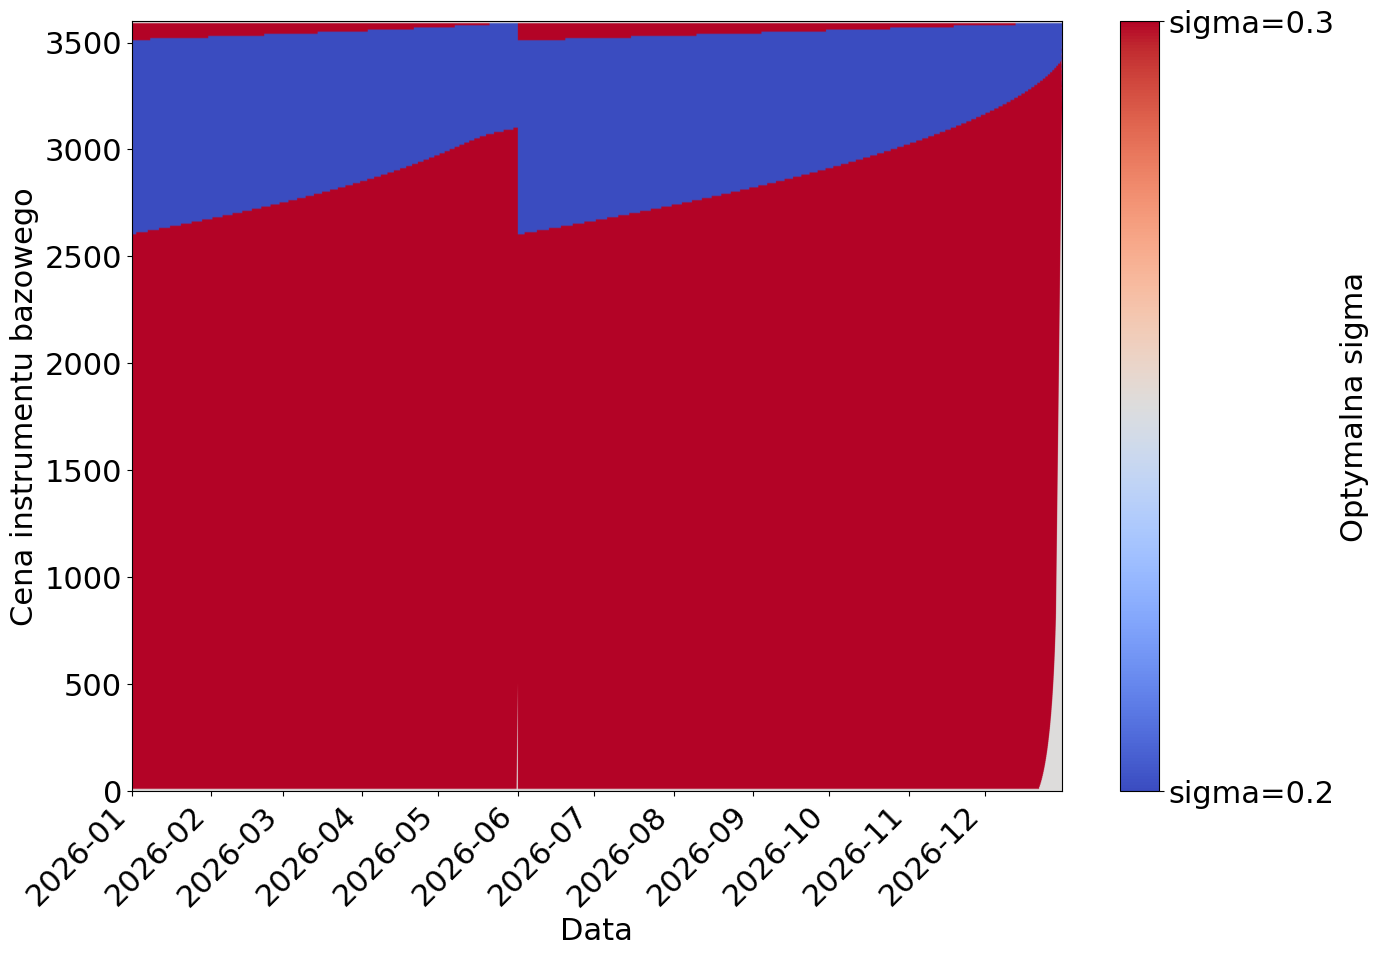

In [23]:
plt.rcParams.update({'font.size': 22})
plt.figure(figsize=(15, 10))
plt.imshow(efd_eur_call.optimal_sigma_grid[:,::-1], origin='lower', aspect='auto', cmap='coolwarm',extent=[efd_eur_call.T0, efd_eur_call.expiry_date, 0, efd_eur_call.N * efd_eur_call.delta_s])
cbar = plt.colorbar(label='Optymalna sigma',ticks=[0,1])
cbar.ax.set_yticklabels([f'sigma={efd_eur_call.sigma_min}', f'sigma={efd_eur_call.sigma_max}'])
plt.xticks(rotation=45, ha='right')
plt.xlabel("Data")
plt.ylabel("Cena instrumentu bazowego")
plt.show()

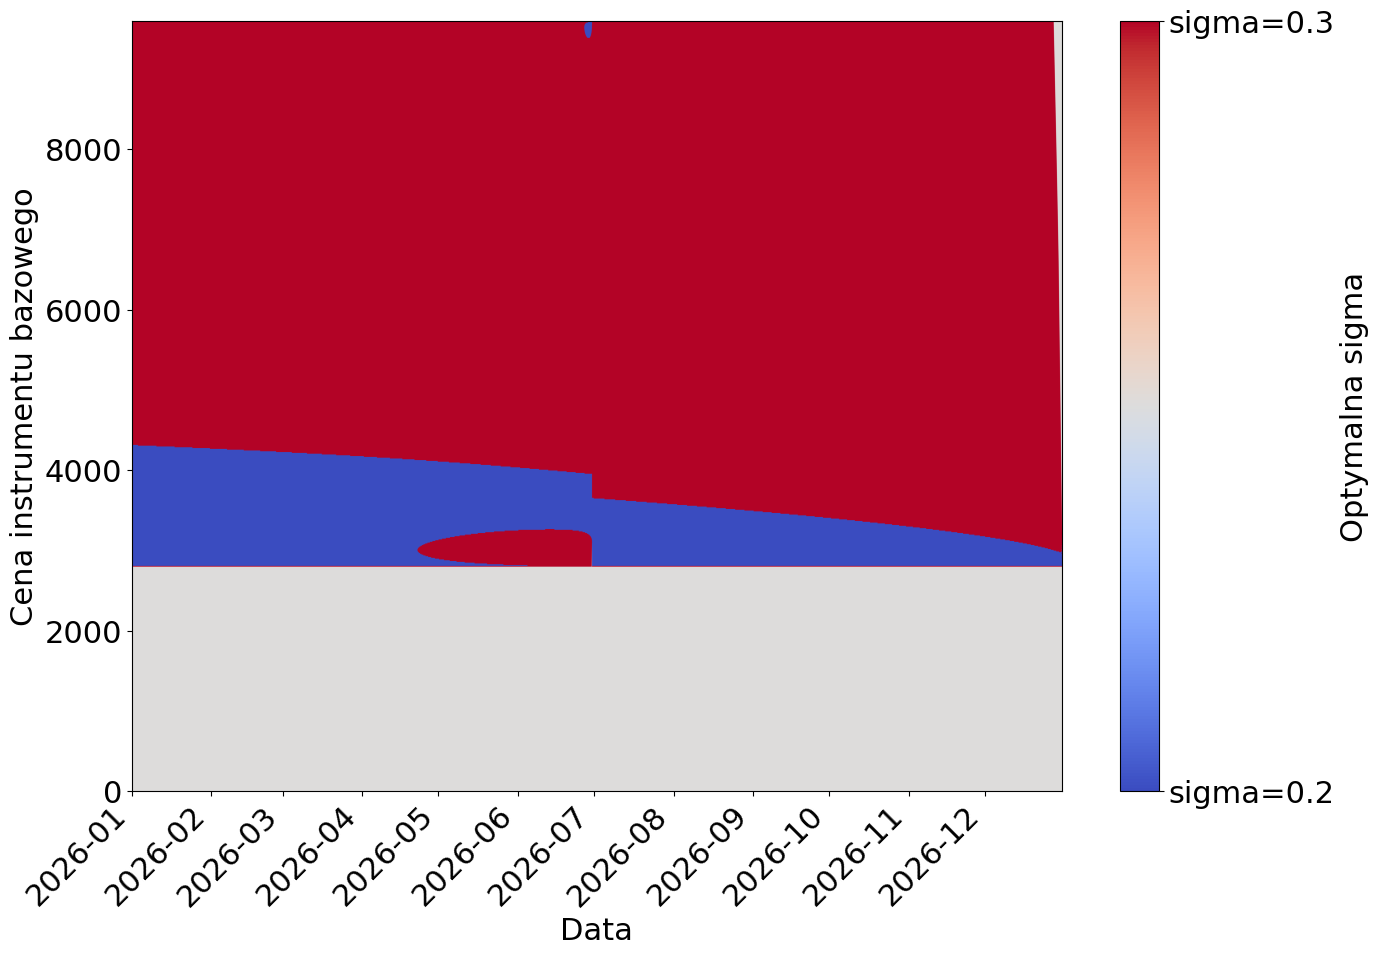

In [24]:
plt.rcParams.update({'font.size': 22})
plt.figure(figsize=(15, 10))
plt.imshow(efd_eur_put.optimal_sigma_grid[:,::-1], origin='lower', aspect='auto', cmap='coolwarm',extent=[efd_eur_put.T0, efd_eur_put.expiry_date, 0, efd_eur_put.N * efd_eur_put.delta_s])
cbar = plt.colorbar(label='Optymalna sigma',ticks=[0,1])
cbar.ax.set_yticklabels([f'sigma={efd_eur_put.sigma_min}', f'sigma={efd_eur_put.sigma_max}'])
plt.xlabel("Data")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Cena instrumentu bazowego")
plt.show()

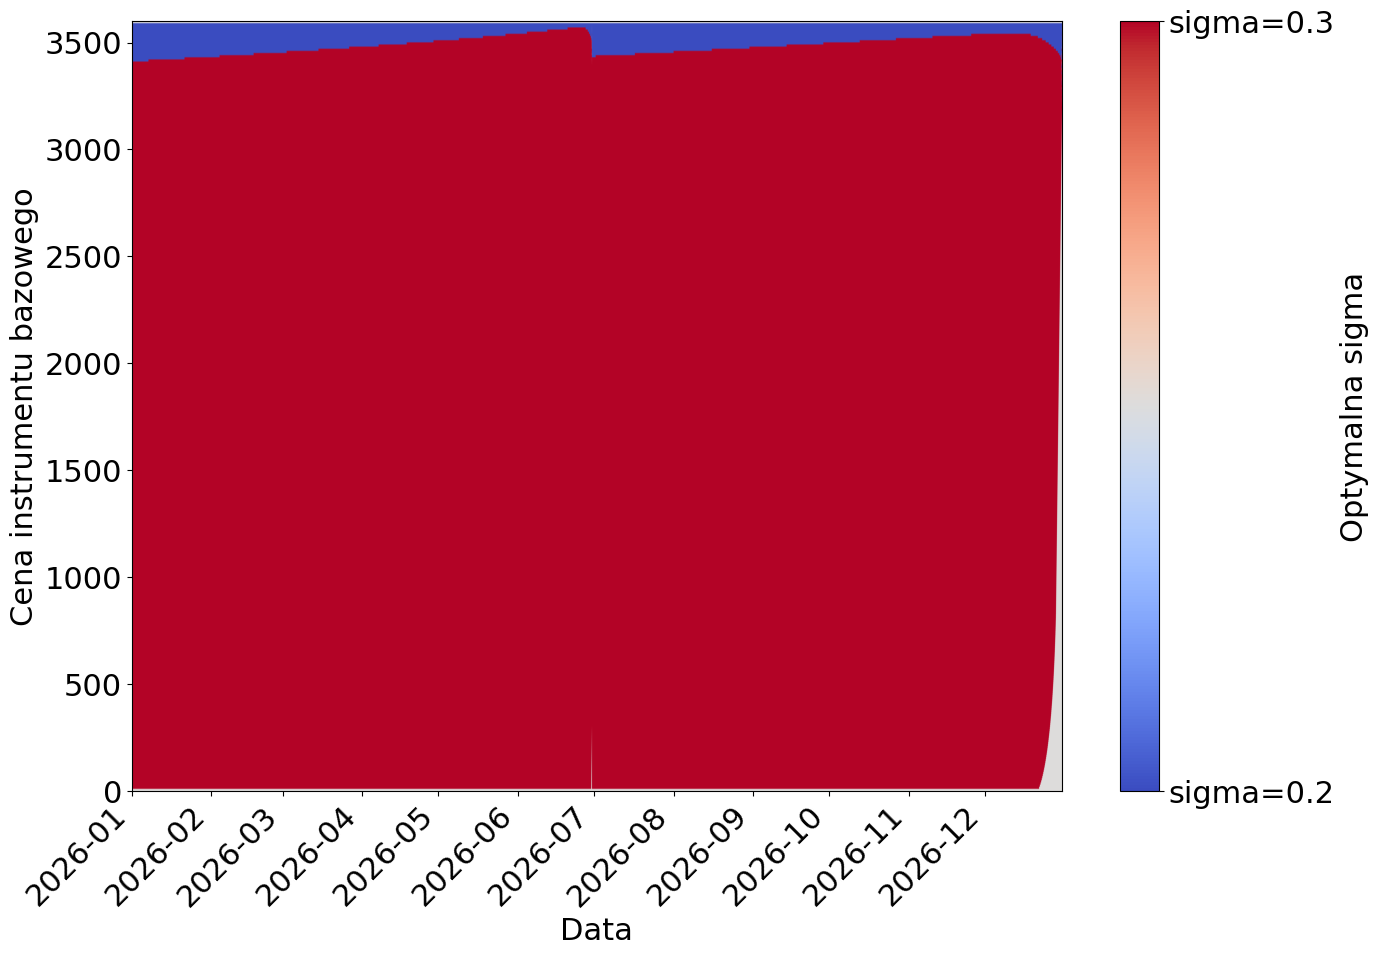

In [25]:
plt.rcParams.update({'font.size': 22})
plt.figure(figsize=(15, 10))
plt.imshow(efd_ame_call.optimal_sigma_grid[:,::-1], origin='lower', aspect='auto', cmap='coolwarm',extent=[efd_ame_call.T0, efd_ame_call.expiry_date, 0, efd_ame_call.N * efd_ame_call.delta_s])
cbar = plt.colorbar(label='Optymalna sigma',ticks=[0,1])
cbar.ax.set_yticklabels([f'sigma={efd_ame_call.sigma_min}', f'sigma={efd_ame_call.sigma_max}'])
plt.xlabel("Data")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Cena instrumentu bazowego")
plt.show()

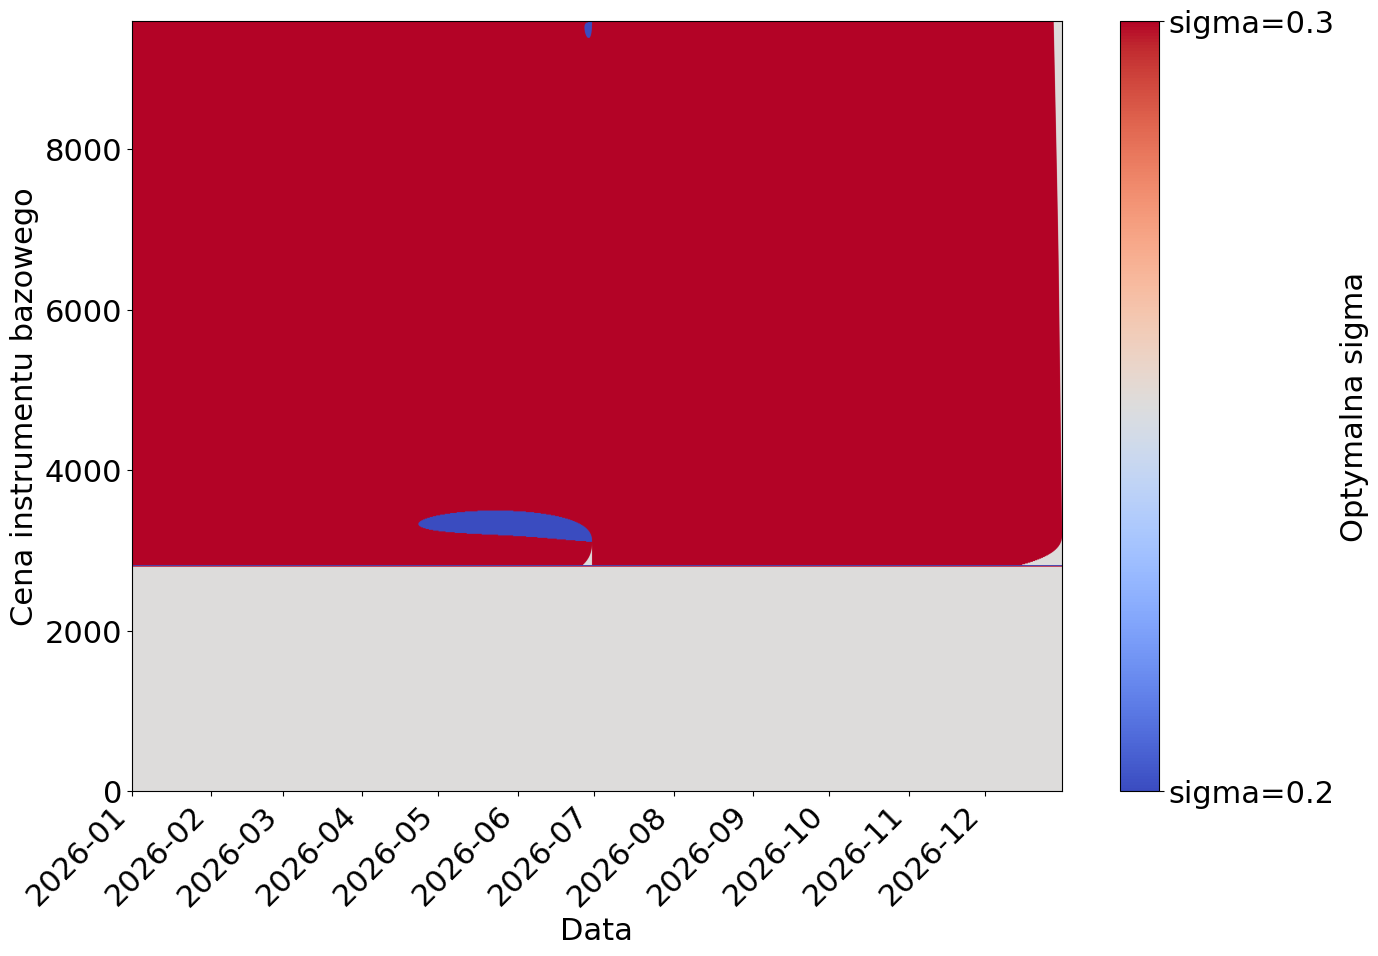

In [26]:
plt.rcParams.update({'font.size': 22})
plt.figure(figsize=(15, 10))
plt.imshow(efd_ame_put.optimal_sigma_grid[:,::-1], origin='lower', aspect='auto', cmap='coolwarm',extent=[efd_ame_put.T0, efd_ame_put.expiry_date, 0, efd_ame_put.N * efd_ame_put.delta_s])
cbar = plt.colorbar(label='Optymalna sigma',ticks=[0,1])
cbar.ax.set_yticklabels([f'sigma={efd_ame_put.sigma_min}', f'sigma={efd_ame_put.sigma_max}'])
plt.xlabel("Data")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Cena instrumentu bazowego")
plt.show()

# Rozważania związane z dywindendą

## Symulacja dla różnych wartości dywidendy x

Initialized grid with shape: (361, 36401)
Initialized grid with shape: (361, 36401)
Initialized grid with shape: (361, 36401)
Initialized grid with shape: (361, 36401)
Initialized grid with shape: (361, 36401)
Initialized grid with shape: (361, 36401)
Initialized grid with shape: (361, 36401)


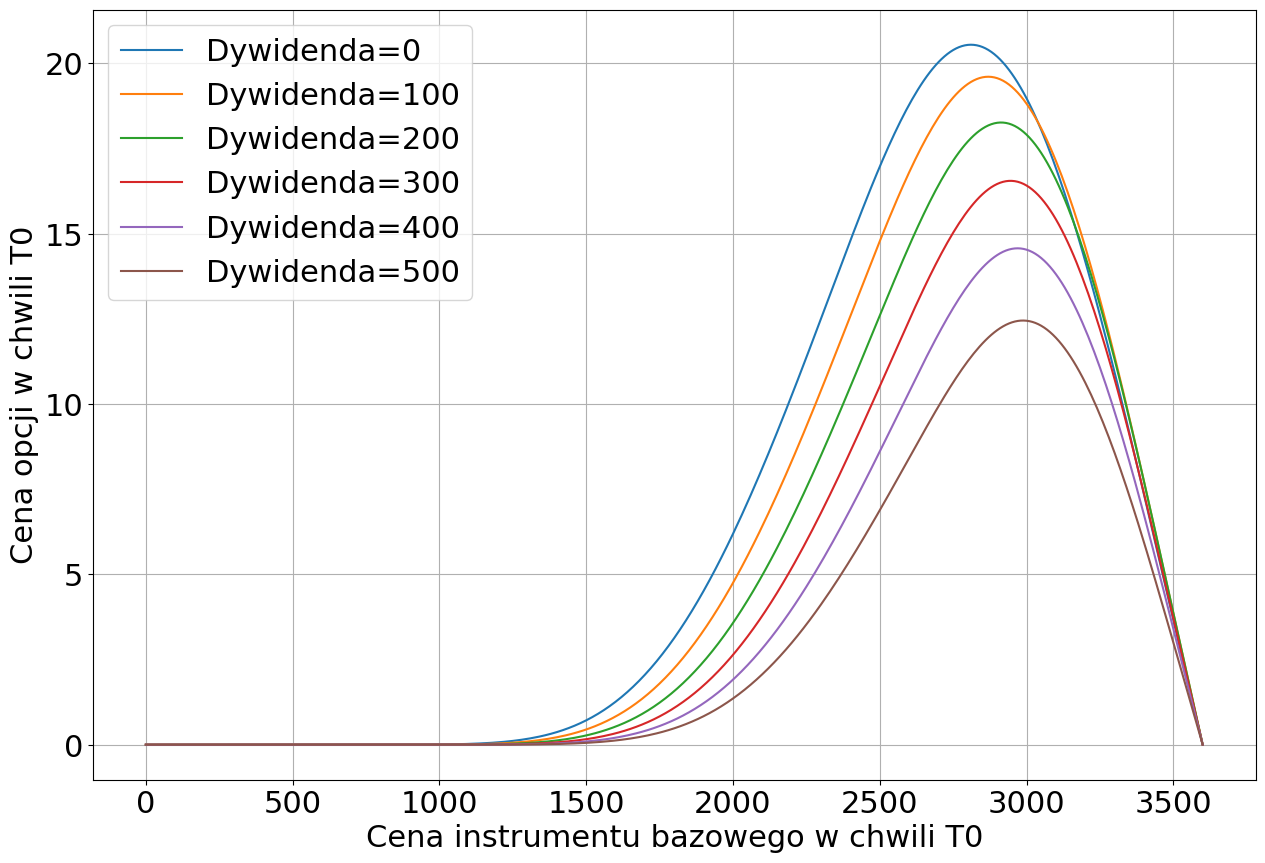

In [34]:
efd_eur_call = EFD(
    sigma_min=0.2,
    sigma_max=0.3,
    option_basic_type=OptionBasicType.CALL,
    option_exercise_type=OptionExerciseType.EUROPEAN,
    expiry_date=datetime(2026, 12, 31),
    T0=datetime(2026, 1, 1),
    strike_price=3200,
    barrier_price=3600,
    r=0.05,
    
    delta_t=1/(365 * 100),
    delta_s=10,

    dividend_type=DividendType.FIXED_AMOUNT,
    dividend_yield=500,
    dividend_date=datetime(2026, 6, 1),

    verbose=True
)



dividends = [0,100,200,300,400,500]

fig, ax = plt.subplots(figsize=(15, 10))

for d in dividends:
    efd_eur_call.dividend_yield = d
    efd_eur_call.initialize_grid()
    efd_eur_call.calculate_grid()
    option_prices = efd_eur_call.get_option_prices_T0()

    X = np.arange(efd_eur_call.N + 1) * efd_eur_call.delta_s
    plt.plot(X, option_prices, label=f"Dywidenda={d}")

    
plt.xlabel("Cena instrumentu bazowego w chwili T0")
plt.ylabel("Cena opcji w chwili T0")
plt.grid()
plt.legend()
plt.show()

Initialized grid with shape: (961, 91001)
Initialized grid with shape: (961, 91001)
Initialized grid with shape: (961, 91001)
Initialized grid with shape: (961, 91001)
Initialized grid with shape: (961, 91001)
Initialized grid with shape: (961, 91001)
Initialized grid with shape: (961, 91001)


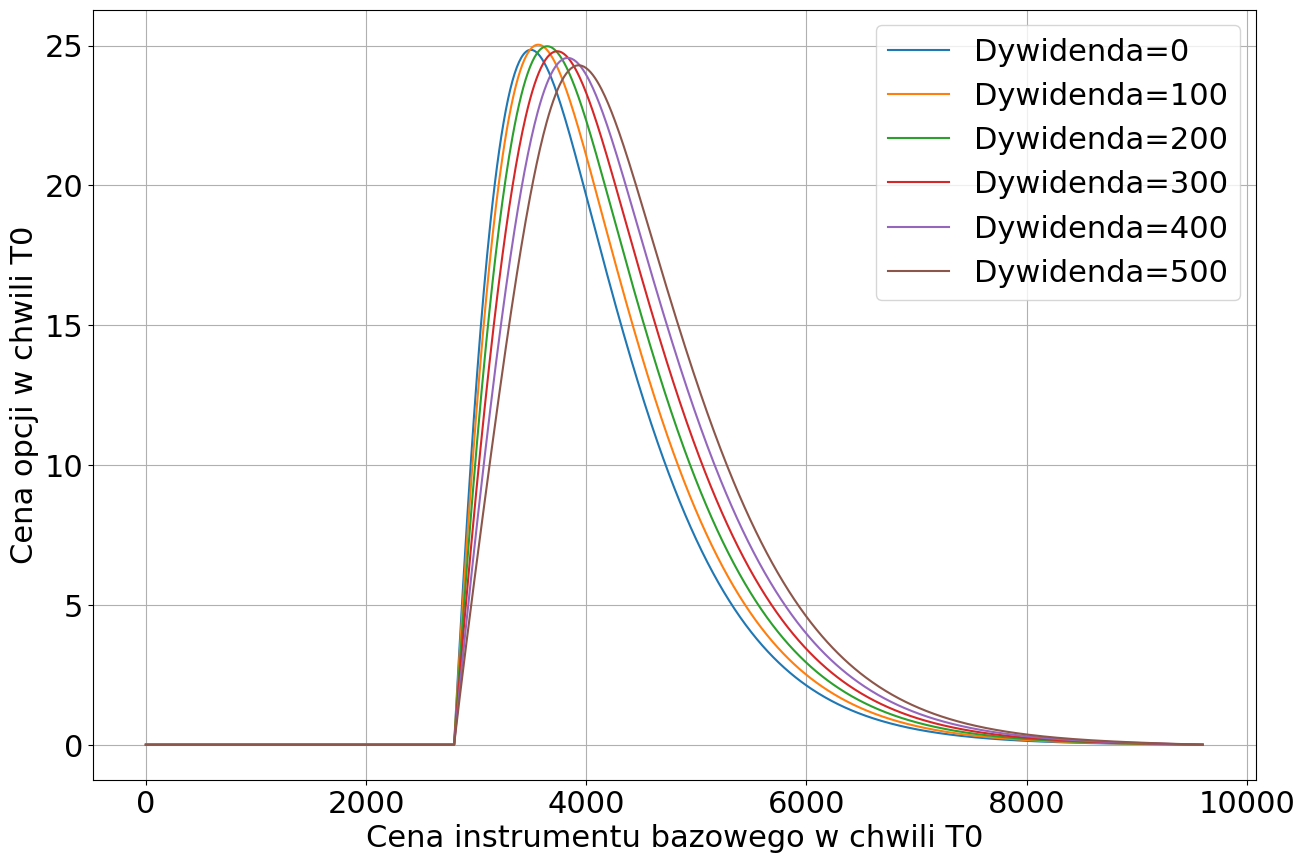

In [35]:
efd_eur_put = EFD(
    sigma_min=0.2,
    sigma_max=0.3,
    option_basic_type=OptionBasicType.PUT,
    option_exercise_type=OptionExerciseType.EUROPEAN,
    expiry_date=datetime(2026, 12, 31),
    T0=datetime(2026, 1, 1),
    strike_price=3200,
    barrier_price=2800,
    r=0.05,
    
    delta_t=1/(365 * 250),
    delta_s=10,

    dividend_type=DividendType.FIXED_AMOUNT,
    dividend_yield=500,
    dividend_date=datetime(2026, 6, 1),

    verbose=True
)



dividends = [0,100,200,300,400,500]

fig, ax = plt.subplots(figsize=(15, 10))

for d in dividends:
    efd_eur_put.dividend_yield = d
    efd_eur_put.initialize_grid()
    efd_eur_put.calculate_grid()
    option_prices = efd_eur_put.get_option_prices_T0()

    X = np.arange(efd_eur_put.N + 1) * efd_eur_put.delta_s
    plt.plot(X, option_prices, label=f"Dywidenda={d}")

    
plt.xlabel("Cena instrumentu bazowego w chwili T0")
plt.ylabel("Cena opcji w chwili T0")
plt.grid()
plt.legend()
plt.show()

Initialized grid with shape: (361, 36401)
Initialized grid with shape: (361, 36401)
Initialized grid with shape: (361, 36401)
Initialized grid with shape: (361, 36401)
Initialized grid with shape: (361, 36401)
Initialized grid with shape: (361, 36401)
Initialized grid with shape: (361, 36401)


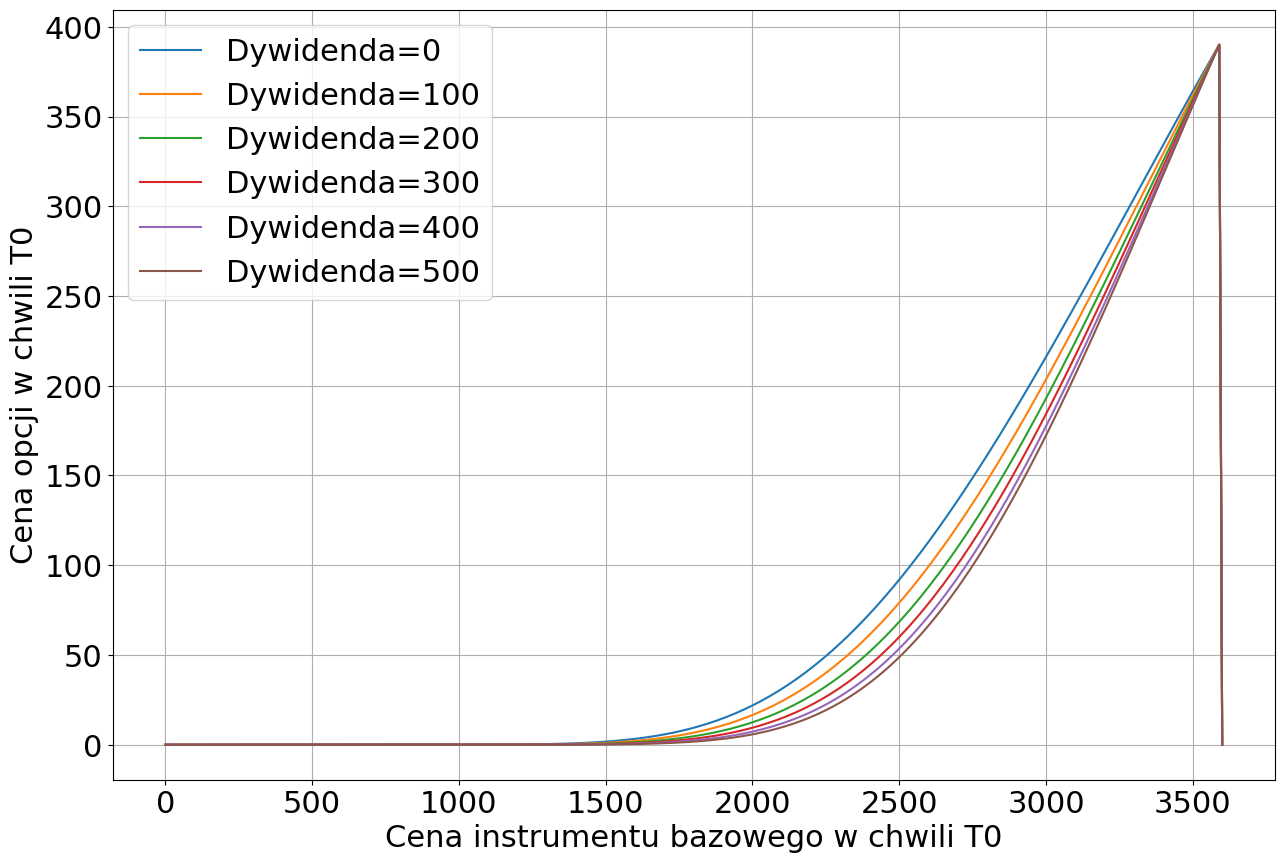

In [36]:
efd_ame_call = EFD(
    sigma_min=0.2,
    sigma_max=0.3,
    option_basic_type=OptionBasicType.CALL,
    option_exercise_type=OptionExerciseType.AMERICAN,
    expiry_date=datetime(2026, 12, 31),
    T0=datetime(2026, 1, 1),
    strike_price=3200,
    barrier_price=3600,
    r=0.05,
    
    delta_t=1/(365 * 100),
    delta_s=10,

    dividend_type=DividendType.FIXED_AMOUNT,
    dividend_yield=300,
    dividend_date=datetime(2026, 6, 30),

    verbose=True
)



dividends = [0,100,200,300,400,500]

fig, ax = plt.subplots(figsize=(15, 10))

for d in dividends:
    efd_ame_call.dividend_yield = d
    efd_ame_call.initialize_grid()
    efd_ame_call.calculate_grid()
    option_prices = efd_ame_call.get_option_prices_T0()

    X = np.arange(efd_ame_call.N + 1) * efd_ame_call.delta_s
    plt.plot(X, option_prices, label=f"Dywidenda={d}")

    
plt.xlabel("Cena instrumentu bazowego w chwili T0")
plt.ylabel("Cena opcji w chwili T0")
plt.grid()
plt.legend()
plt.show()

Initialized grid with shape: (961, 91001)
Initialized grid with shape: (961, 91001)
Initialized grid with shape: (961, 91001)
Initialized grid with shape: (961, 91001)
Initialized grid with shape: (961, 91001)
Initialized grid with shape: (961, 91001)
Initialized grid with shape: (961, 91001)


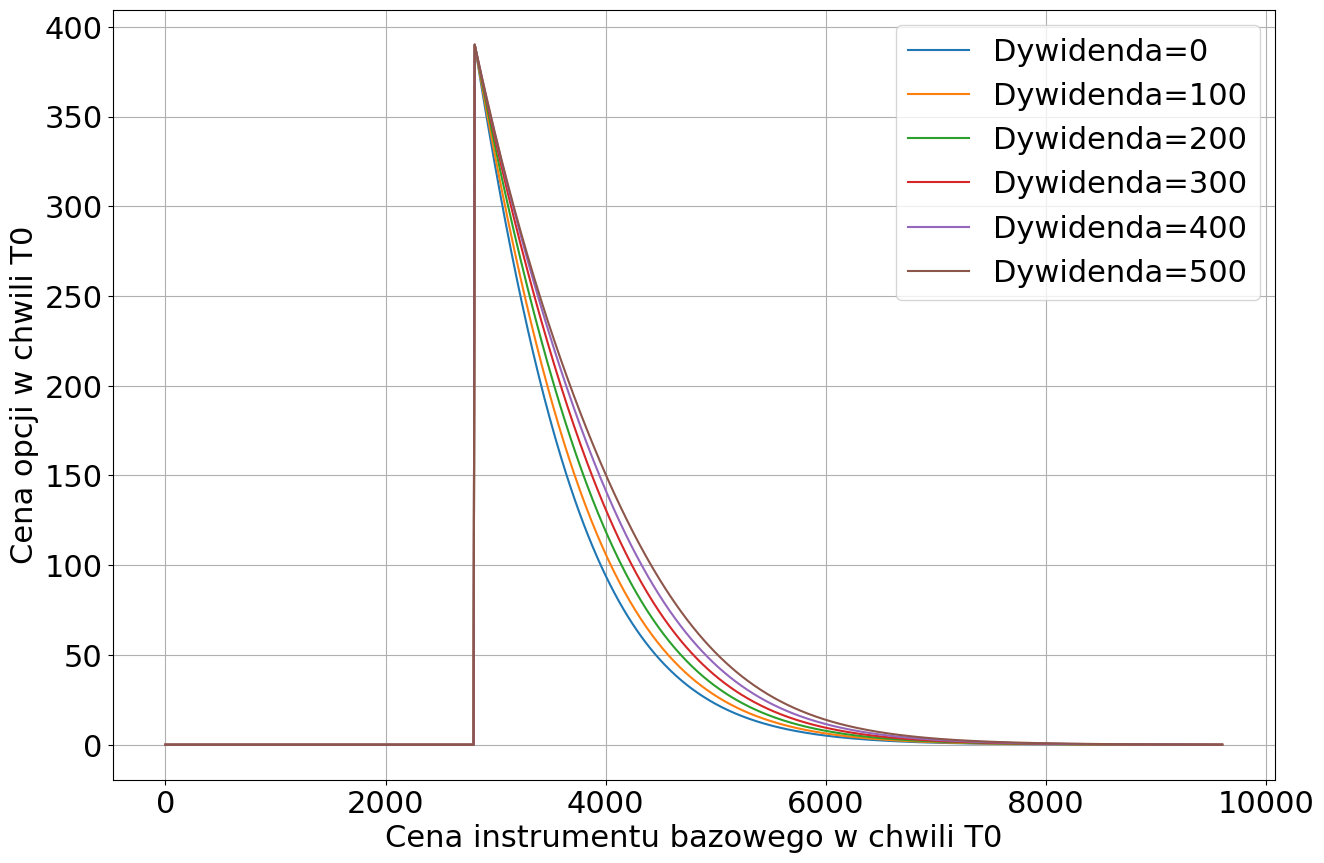

In [37]:
efd_ame_put = EFD(
    sigma_min=0.2,
    sigma_max=0.3,
    option_basic_type=OptionBasicType.PUT,
    option_exercise_type=OptionExerciseType.AMERICAN,
    expiry_date=datetime(2026, 12, 31),
    T0=datetime(2026, 1, 1),
    strike_price=3200,
    barrier_price=2800,
    r=0.05,
    
    delta_t=1/(365 * 250),
    delta_s=10,

    dividend_type=DividendType.FIXED_AMOUNT,
    dividend_yield=300,
    dividend_date=datetime(2026, 6, 30),

    verbose=True
)



dividends = [0,100,200,300,400,500]

fig, ax = plt.subplots(figsize=(15, 10))

for d in dividends:
    efd_ame_put.dividend_yield = d
    efd_ame_put.initialize_grid()
    efd_ame_put.calculate_grid()
    option_prices = efd_ame_put.get_option_prices_T0()

    X = np.arange(efd_ame_put.N + 1) * efd_ame_put.delta_s
    plt.plot(X, option_prices, label=f"Dywidenda={d}")

    
plt.xlabel("Cena instrumentu bazowego w chwili T0")
plt.ylabel("Cena opcji w chwili T0")
plt.grid()
plt.legend()
plt.show()

# Rozważania, jeżeli dywidenda byłaby ułamkiem ceny instrumentu bazowego

Initialized grid with shape: (361, 36401)
Initialized grid with shape: (361, 36401)
Initialized grid with shape: (361, 36401)
Initialized grid with shape: (361, 36401)
Initialized grid with shape: (361, 36401)
Initialized grid with shape: (361, 36401)
Initialized grid with shape: (361, 36401)


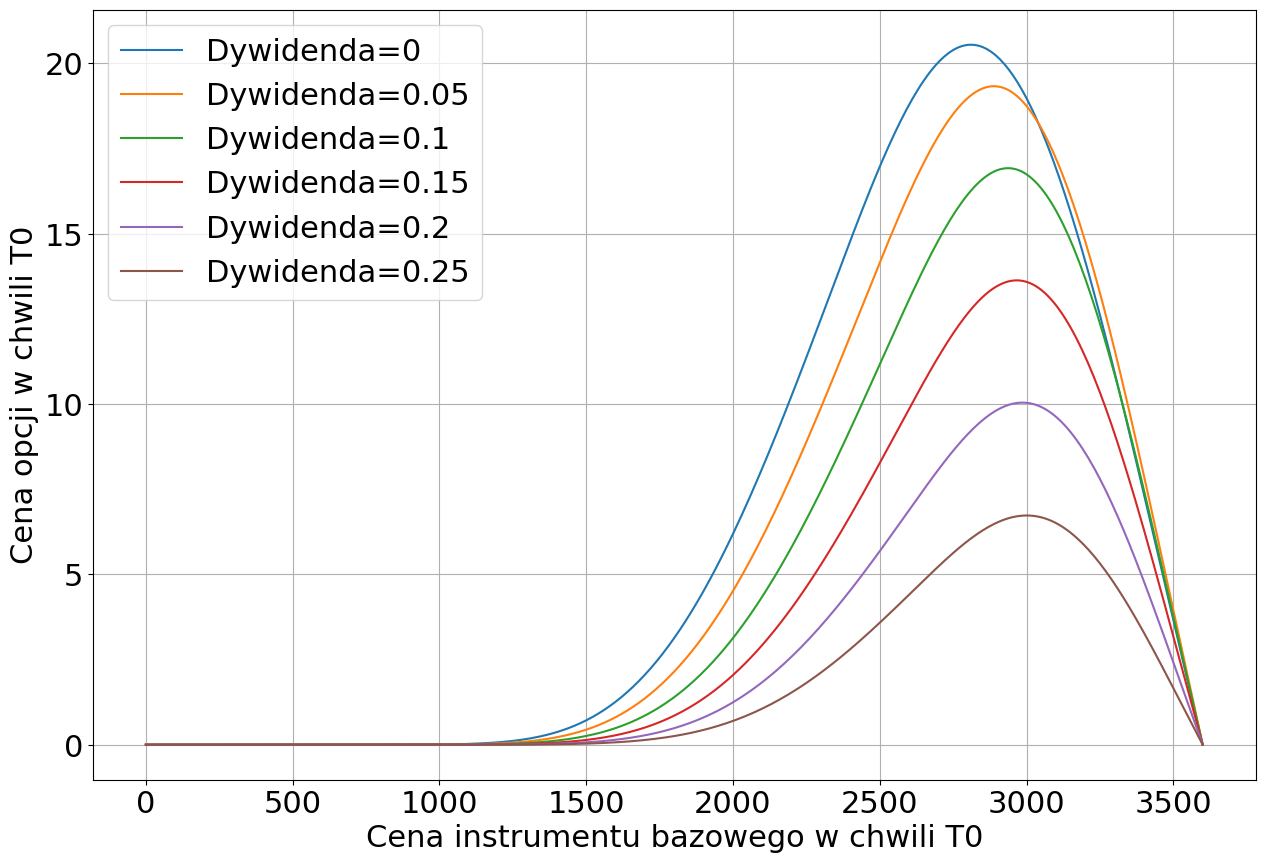

In [38]:
efd = EFD(
    sigma_min=0.2,
    sigma_max=0.3,
    option_basic_type=OptionBasicType.CALL,
    option_exercise_type=OptionExerciseType.EUROPEAN,
    expiry_date=datetime(2026, 12, 31),
    T0=datetime(2026, 1, 1),
    strike_price=3200,
    barrier_price=3600,
    r=0.05,
    
    delta_t=1/(365 * 100),
    delta_s=10,

    dividend_type=DividendType.FIXED_YIELD,
    dividend_yield=0,
    dividend_date=datetime(2026, 6, 1),

    verbose=True
)



dividends = [0,0.05,0.1,0.15,0.2,0.25]

Ys = []

fig, ax = plt.subplots(figsize=(15, 10))

for d in dividends:
    efd.dividend_yield = d
    efd.initialize_grid()
    efd.calculate_grid()
    option_prices = efd.get_option_prices_T0()

    X = np.arange(efd.N + 1) * efd.delta_s
    plt.plot(X, option_prices, label=f"Dywidenda={d}")
    Ys.append(option_prices.copy())

    
plt.xlabel("Cena instrumentu bazowego w chwili T0")
plt.ylabel("Cena opcji w chwili T0")
plt.grid()
plt.legend()
plt.show()

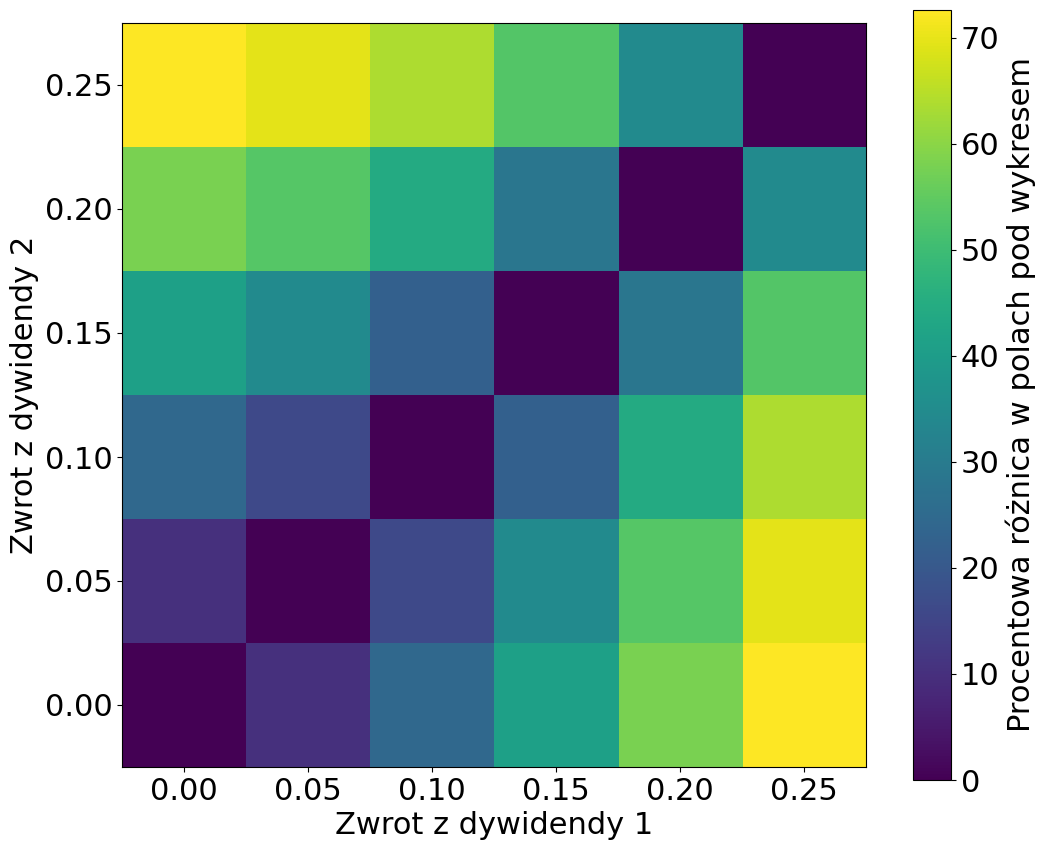

In [44]:
diff_matrix = np.zeros((len(dividends), len(dividends)))

for i, d1 in enumerate(dividends):
    for j, d2 in enumerate(dividends):
        big = np.sum(Ys[min(i,j)])
        small = np.sum(Ys[max(i,j)])
        diff_matrix[i,j] = (big - small) / big * 100


plt.figure(figsize=(12, 10))
plt.imshow(diff_matrix, origin='lower', cmap='viridis', extent=[0, len(dividends), 0, len(dividends)])
plt.colorbar(label='Procentowa różnica w polach pod wykresem')
plt.xticks(np.arange(len(dividends)) + 0.5, [f"{d:.2f}" for d in dividends])
plt.yticks(np.arange(len(dividends)) + 0.5, [f"{d:.2f}" for d in dividends])
plt.xlabel("Zwrot z dywidendy 1")
plt.ylabel("Zwrot z dywidendy 2")
plt.show()

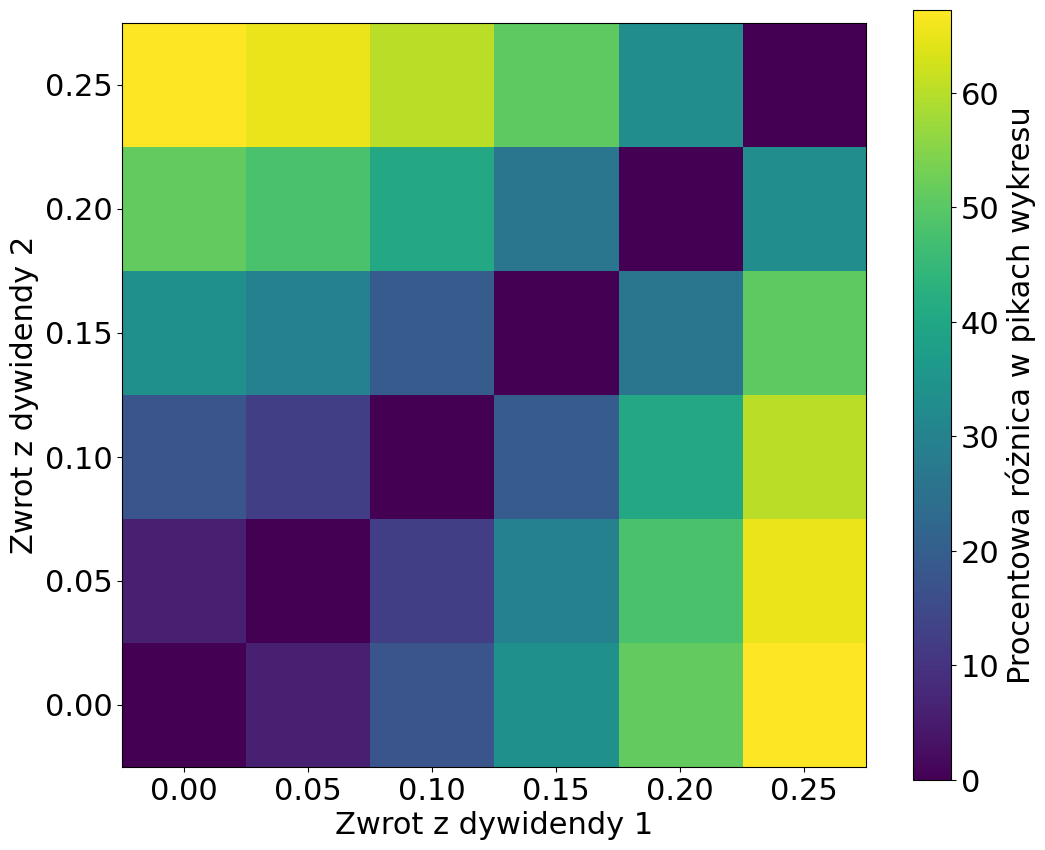

In [45]:
diff_matrix = np.zeros((len(dividends), len(dividends)))

for i, d1 in enumerate(dividends):
    for j, d2 in enumerate(dividends):
        big = np.sum(np.max(Ys[min(i,j)]))
        small = np.sum(np.max(Ys[max(i,j)]))
        diff_matrix[i,j] = (big - small) / big * 100


plt.figure(figsize=(12, 10))
plt.imshow(diff_matrix, origin='lower', cmap='viridis', extent=[0, len(dividends), 0, len(dividends)])
plt.colorbar(label='Procentowa różnica w pikach wykresu')
plt.xticks(np.arange(len(dividends)) + 0.5, [f"{d:.2f}" for d in dividends])
plt.yticks(np.arange(len(dividends)) + 0.5, [f"{d:.2f}" for d in dividends])
plt.xlabel("Zwrot z dywidendy 1")
plt.ylabel("Zwrot z dywidendy 2")
plt.show()

# Wniosek
Zmiana mierzona względem wartości maksymalnej dla S i względem pól jest bardzo podobna